=== EJECUTANDO 3 ESQUEMAS ===


>>> Exploratorio
  Gen 0: -51.0
  Gen 10: -51.0
  Gen 20: -51.0
   Final: -51.0

>>> Equilibrado
  Gen 0: -51.0
  Gen 10: -48.0
  Gen 20: -48.0
   Final: -48.0

>>> Exploitativo
  Gen 0: -51.0
  Gen 10: -51.0
  Gen 20: -51.0
   Final: -51.0


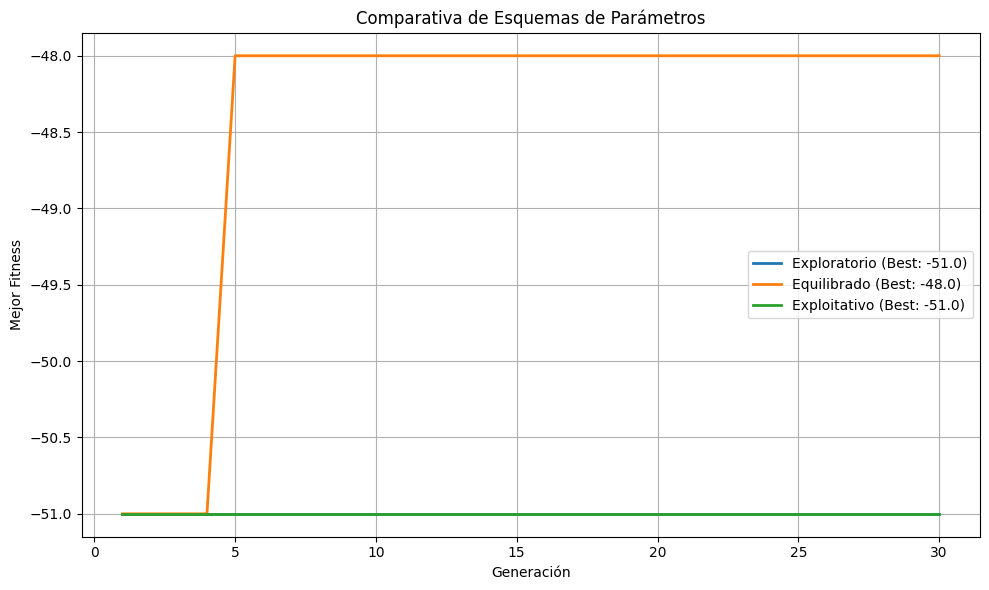


=== RESULTADOS ===
Exploratorio: -51.00
Equilibrado: -48.00
Exploitativo: -51.00

MEJOR ESQUEMA: Equilibrado


In [2]:
import random
import copy
import time
import blosum
import matplotlib.pyplot as plt

blosum62 = blosum.BLOSUM(62)

# SECUENCIAS CORTAS (solo 30-40 aminoácidos)
def get_sequences():
    seq1 = "MGSSHHHHHHSSGLVPRGSHMASMTGGQQMGRDLYDDDDKDRW"
    seq2 = "MKTLLVAAAVVAGGQGQAEKLVKQLEQKAKELQKQLEQKAKEL"
    seq3 = "MAVTQGQKLVVLGAGGVGKSALTIQLIQNHFVDEYDPTIEDSY"
    return [list(seq1), list(seq2), list(seq3)]

def crear_poblacion_inicial(n):
    base = get_sequences()
    return [[row[:] for row in base] for _ in range(n)]

def igualar(individuo):
    max_len = max(len(f) for f in individuo)
    return [f + ['-']*(max_len - len(f)) for f in individuo]

def evaluar(individuo, penal):
    score = 0
    for col in range(len(individuo[0])):
        for i in range(3):
            for j in range(i+1, 3):
                a, b = individuo[i][col], individuo[j][col]
                if a == '-' or b == '-':
                    score += penal
                else:
                    score += blosum62[a][b]
    return score

def mutar(individuo, n_gaps, prob):
    nuevo = []
    for seq in individuo:
        s = seq[:]
        if random.random() < prob:
            for _ in range(n_gaps):
                s.insert(random.randint(0, len(s)), '-')
        nuevo.append(s)
    return nuevo

def cruzar(ind1, ind2, n_gaps, prob):
    h1, h2 = [], []
    for s1, s2 in zip(ind1, ind2):
        idx = [i for i, a in enumerate(s1) if a != '-']
        if len(idx) < 4:
            h1.append(s1[:]); h2.append(s2[:]); continue
        p1, p2 = sorted(random.sample(idx, 2))
        aa1 = [a for a in s1 if a != '-']
        aa2 = [a for a in s2 if a != '-']
        new1 = aa1[:p1] + aa2[p1:p2] + aa1[p2:]
        new2 = aa2[:p1] + aa1[p1:p2] + aa2[p2:]
        def reconstruir(orig, new):
            res, i = [], 0
            for a in orig:
                if a == '-': res.append('-')
                else: res.append(new[i]); i += 1
            return res
        h1.append(reconstruir(s1, new1))
        h2.append(reconstruir(s2, new2))
    return mutar(h1, n_gaps, prob), mutar(h2, n_gaps, prob)

def seleccionar(poblacion, scores, pct):
    n = max(2, int(len(poblacion) * pct))
    parejas = list(zip(scores, poblacion))
    parejas.sort(reverse=True, key=lambda x: x[0])
    return [p for _, p in parejas[:n]], [s for s, _ in parejas[:n]]

def ejecutar(pop_size, gens, elite, gaps, prob_mut, penal):
    poblacion = [igualar(ind) for ind in crear_poblacion_inicial(pop_size)]
    scores = [evaluar(ind, penal) for ind in poblacion]
    poblacion, scores = seleccionar(poblacion, scores, elite)
    
    historial = []
    for gen in range(gens):
        nueva = []
        for i in range(0, len(poblacion), 2):
            if i+1 < len(poblacion):
                h1, h2 = cruzar(poblacion[i], poblacion[i+1], gaps, prob_mut)
                nueva.extend([h1, h2])
        poblacion.extend(nueva)
        poblacion = [igualar(ind) for ind in poblacion]
        scores = [evaluar(ind, penal) for ind in poblacion]
        poblacion, scores = seleccionar(poblacion, scores, elite)
        historial.append(max(scores))
        if gen % 10 == 0:
            print(f"  Gen {gen}: {historial[-1]:.1f}")
    return historial, max(historial)

# ESQUEMAS (población pequeña para rapidez)
esquemas = {
    "Exploratorio": {"pop_size": 8, "gens": 30, "elite": 0.3, "gaps": 2, "prob_mut": 1.0, "penal": -2},
    "Equilibrado":  {"pop_size": 6, "gens": 30, "elite": 0.5, "gaps": 1, "prob_mut": 0.6, "penal": -4},
    "Exploitativo": {"pop_size": 4, "gens": 30, "elite": 0.7, "gaps": 1, "prob_mut": 0.3, "penal": -6}
}

print("=== EJECUTANDO 3 ESQUEMAS ===\n")
resultados = {}
for nombre, p in esquemas.items():
    print(f"\n>>> {nombre}")
    hist, best = ejecutar(**p)
    resultados[nombre] = {"hist": hist, "best": best}
    print(f"   Final: {best:.1f}")

# GRÁFICA
plt.figure(figsize=(10, 6))
for nombre, d in resultados.items():
    plt.plot(range(1, len(d["hist"])+1), d["hist"], label=f"{nombre} (Best: {d['best']:.1f})", linewidth=2)
plt.xlabel("Generación")
plt.ylabel("Mejor Fitness")
plt.title("Comparativa de Esquemas de Parámetros")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("grafica.png")
plt.show()

print("\n=== RESULTADOS ===")
for nombre, d in resultados.items():
    print(f"{nombre}: {d['best']:.2f}")
mejor = max(resultados.keys(), key=lambda x: resultados[x]["best"])
print(f"\nMEJOR ESQUEMA: {mejor}")